# Local-Offline-RAG-tc

This notebook validates a fully offline Traditional Chinese user interaction. The worker asks in Traditional Chinese and provides a field photo. The offline stack uses the local image body/caption, normalizes the intent for local retrieval, searches the local case pack, and returns the final grounded response in Traditional Chinese.

**Scope:** no Azure AI Search, no cloud model, and no online corpus are used in this test.


## Traditional Chinese offline execution path

Phi-4-mini is text-only, so it does not inspect pixels directly. The image is first represented as a local visual caption/body; Phi-4-mini then helps convert the Traditional Chinese field question plus image body into an English retrieval query for the local vector store, and later drafts the final Traditional Chinese answer from retrieved evidence.


Traditional Chinese full-offline query path 繁中問題 + field photo Local image body/caption Phi-4-mini query normalize English retrieval query Image + text query vector Local offline case pack Retrieved evidence Phi-4-mini 繁中 answer

## Test setup

| Item | Value |
| --- | --- |
| Scenario | qry_001_water_ingress |
| Traditional Chinese question | 現場相片顯示地下室擋土牆的施工縫有明顯滲水、牆身有水漬，地面亦有積水。請幫我用過往案例找出最相似的情況，並用繁體中文說明下一步應該怎樣處理，以及甚麼情況需要升級處理。 |
| Query image | `notebooks/assets/real_local_inference/query_images/qry_001_water_ingress_heldout.png` |
| Query image indexed? | False |
| Local image body source | moondream / vikhyatk/moondream2 |
| Offline retrieval inputs | text, image, caption |
| Query rewrite model | microsoft/Phi-4-mini-instruct-onnx |
| Answer model | microsoft/Phi-4-mini-instruct-onnx |


Traditional Chinese question,Normalized English retrieval query
現場相片顯示地下室擋土牆的施工縫有明顯滲水、牆身有水漬，地面亦有積水。請幫我用過往案例找出最相似的情況，並用繁體中文說明下一步應該怎樣處理，以及甚麼情況需要升級處理。,"Construction site leak near concrete wall with large puddle, damp condition, likely structural damage or water intrusion, response and escalation needed"

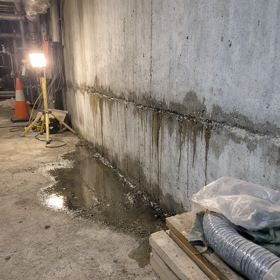
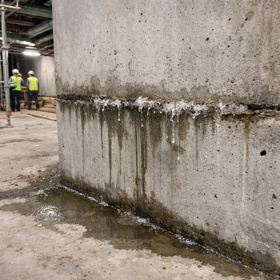

In [2]:
from IPython.display import HTML, display
display(HTML(traditional_chinese_offline_html))


## Query normalization and retrieval result

| Field | Value |
| --- | --- |
| Local image body | A construction-site issue visible is a large puddle of water on the ground near a concrete wall.  The water appears to be leaking from the wall, potentially due to structural damage or water intrusion. The field condition appears to be damp and possibly wet. |
| Normalized English retrieval query | Construction site leak near concrete wall with large puddle, damp condition, likely structural damage or water intrusion, response and escalation needed |
| Top local case | INC-001 - Basement wall water ingress observed at construction joint |
| Top score | 0.8604 |
| Expected case | INC-001 |
| Matched expected? | True |


## Traditional Chinese answer from offline evidence

> 這個情況最相似的是INC-001，因為這個情況中有明顯的滲水和牆身有水漬，這與INC-001情況中的地下室擋土牆的施工縫有明顯滲水相似。
> 下一步應該：
> 1. 對應現象進行標記和拍攝，記錄全範圍的滲水和牆身的水漬。
> 2. 檢查施工縫的詳細結構，檢查膜體連續性和任何穿孔或拉桿孔修補的狀況。
> 3. 檢查周圍的排水系統和集水井的運作狀況，並評估外部水管理條件。
> 4. 將水控措施暫時實施，隔離任何影響電氣設備或敏感表面區域。
> 5. 提出一份修補防水專家進行審核和重新測試的指令。
> 6. 如果滲水量增加、接觸到帶電設備、或顯示牆體移動、裂縫或泥土流失或泥土沖刷的情況，立即升級處理。
> 這是離線的回答，基於本地案例包。


## TC offline conclusion

- The Traditional Chinese question is mapped back to the water-ingress retrieval intent using the local image body/caption.
- The top local retrieval result is `INC-001`, matching the expected case `INC-001`.
- The final response is returned in Traditional Chinese while preserving the local incident citation and escalation rule.
- This confirms the intended language pattern: use Phi-4-mini for query normalization and localized answer drafting, while keeping facts in the offline case pack.
